# Finding pilot patient

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from results_functions import extract_ews, extract_tws, grand_average, plot_all_patients, get_scores_all_patients
from db import patients_db


In [2]:
# Combine ews for all patients
# pickle_name = "performances_v1"
# strategy = "transfer"
pickle_name = "performances_static_v1"
strategy = "static"
clf = "btlda"
score = "ews"

ews_all_static = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_static = grand_average(ews_all_static) 

In [3]:
pickle_name = "performances_v1"
strategy = "transfer"
clf = "btlda"
score = "ews"

ews_all_transfer = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_transfer = grand_average(ews_all_transfer) 

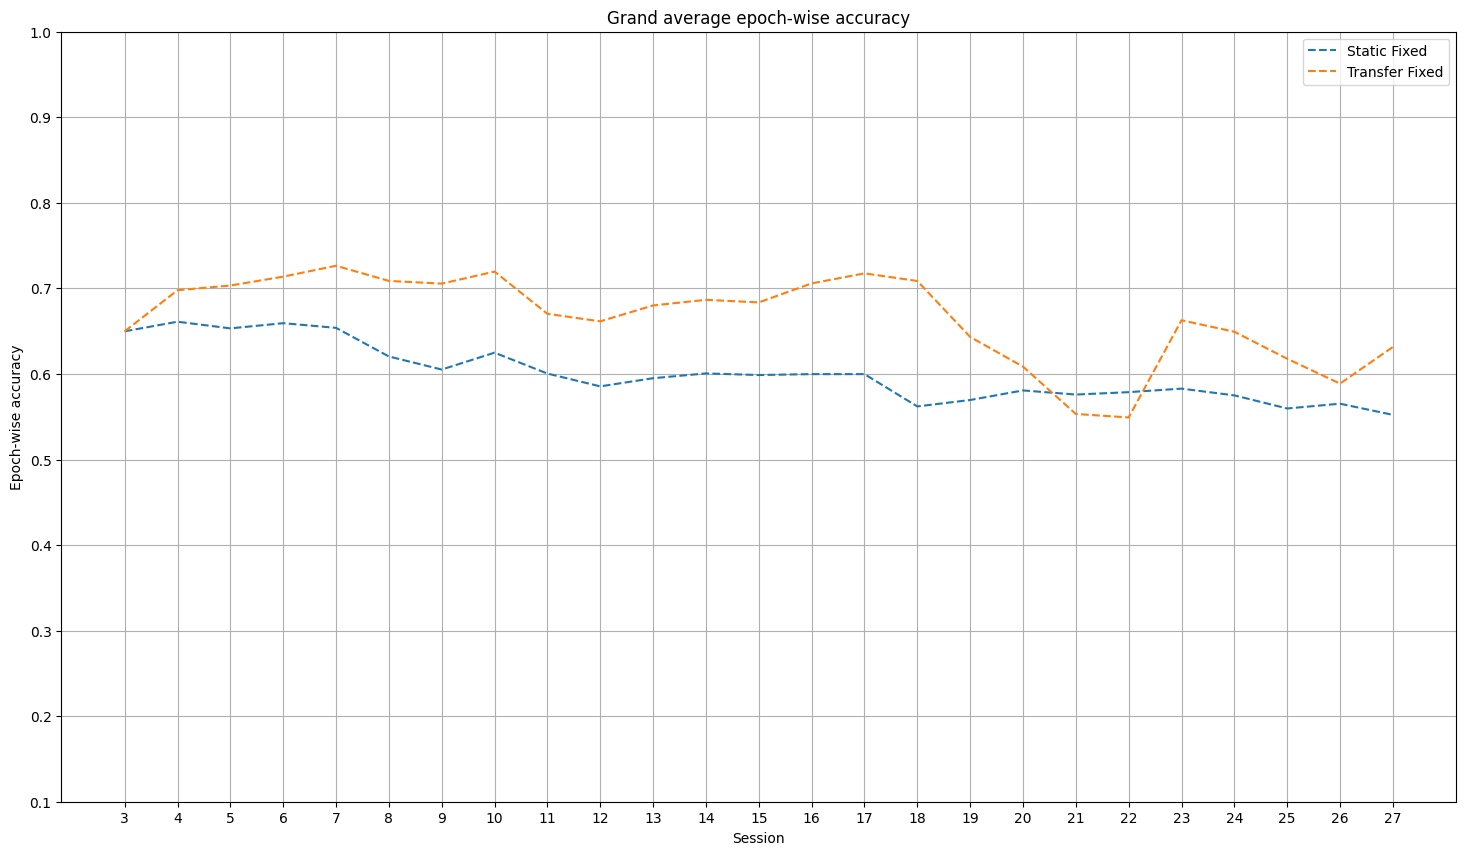

In [4]:
plt.figure(figsize=(18,10))
plt.plot(ews_avg_static, label="Static Fixed", linestyle='dashed')
plt.plot(ews_avg_transfer, label="Transfer Fixed", linestyle='dashed')
plt.ylabel("Epoch-wise accuracy")
plt.xlabel('Session')
plt.ylim(0.1,1)
plt.xticks(np.arange(0,25), np.arange(3,28))    
plt.legend()    
plt.title("Grand average epoch-wise accuracy")   
plt.grid() 
plt.show()

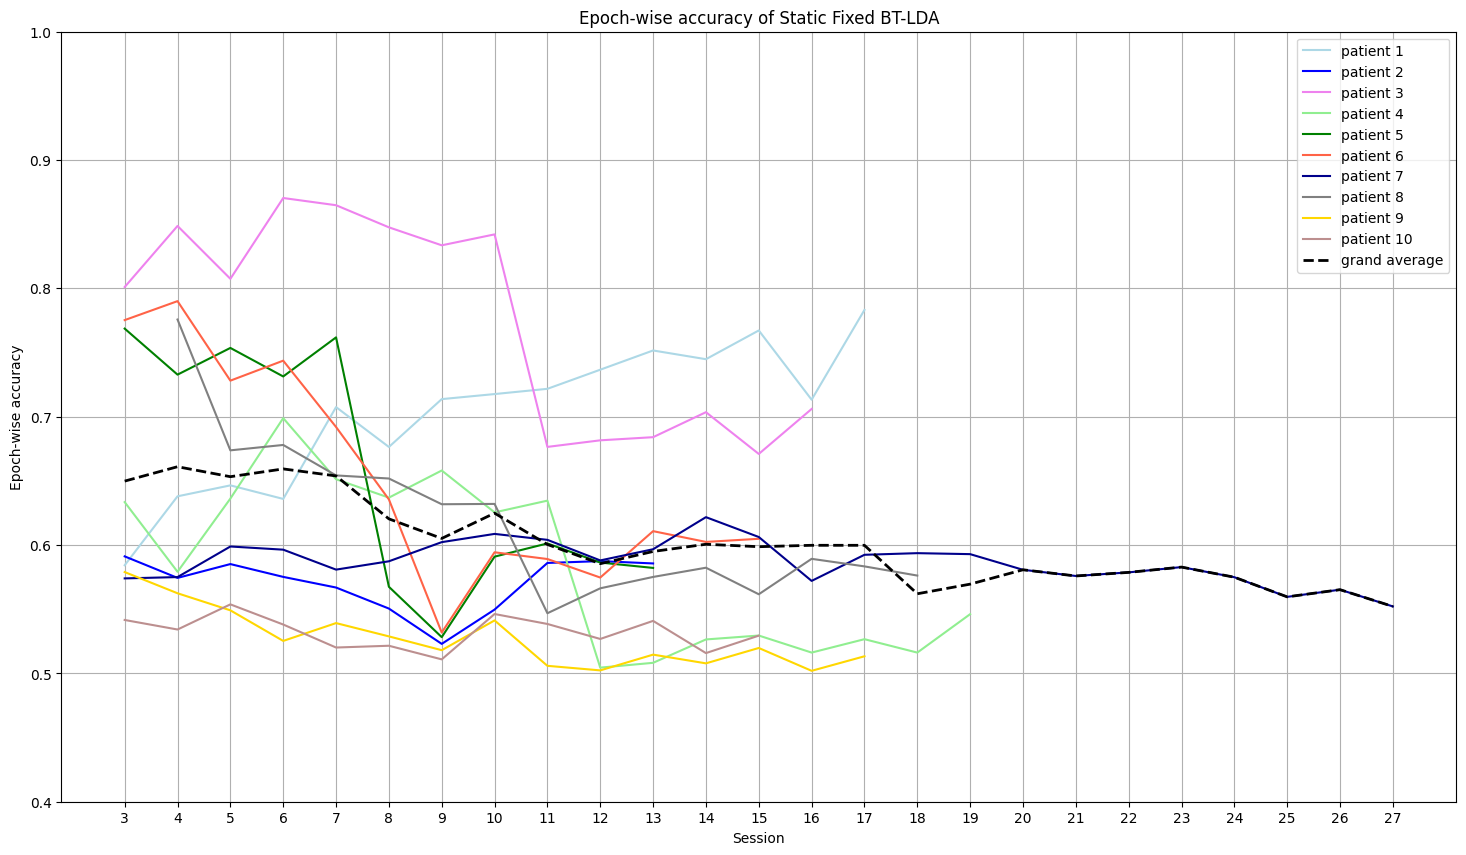

In [5]:

plot_all_patients(ews_all_static, grand_avg=ews_avg_static, title="Epoch-wise accuracy of Static Fixed BT-LDA", ylabel="Epoch-wise accuracy")

In [7]:
pickle_name = "performances_v1"
strategy = "transfer"
clf = "btlda"
score = "tws"

tws_scores = get_scores_all_patients(pickle_name, strategy, clf, score)

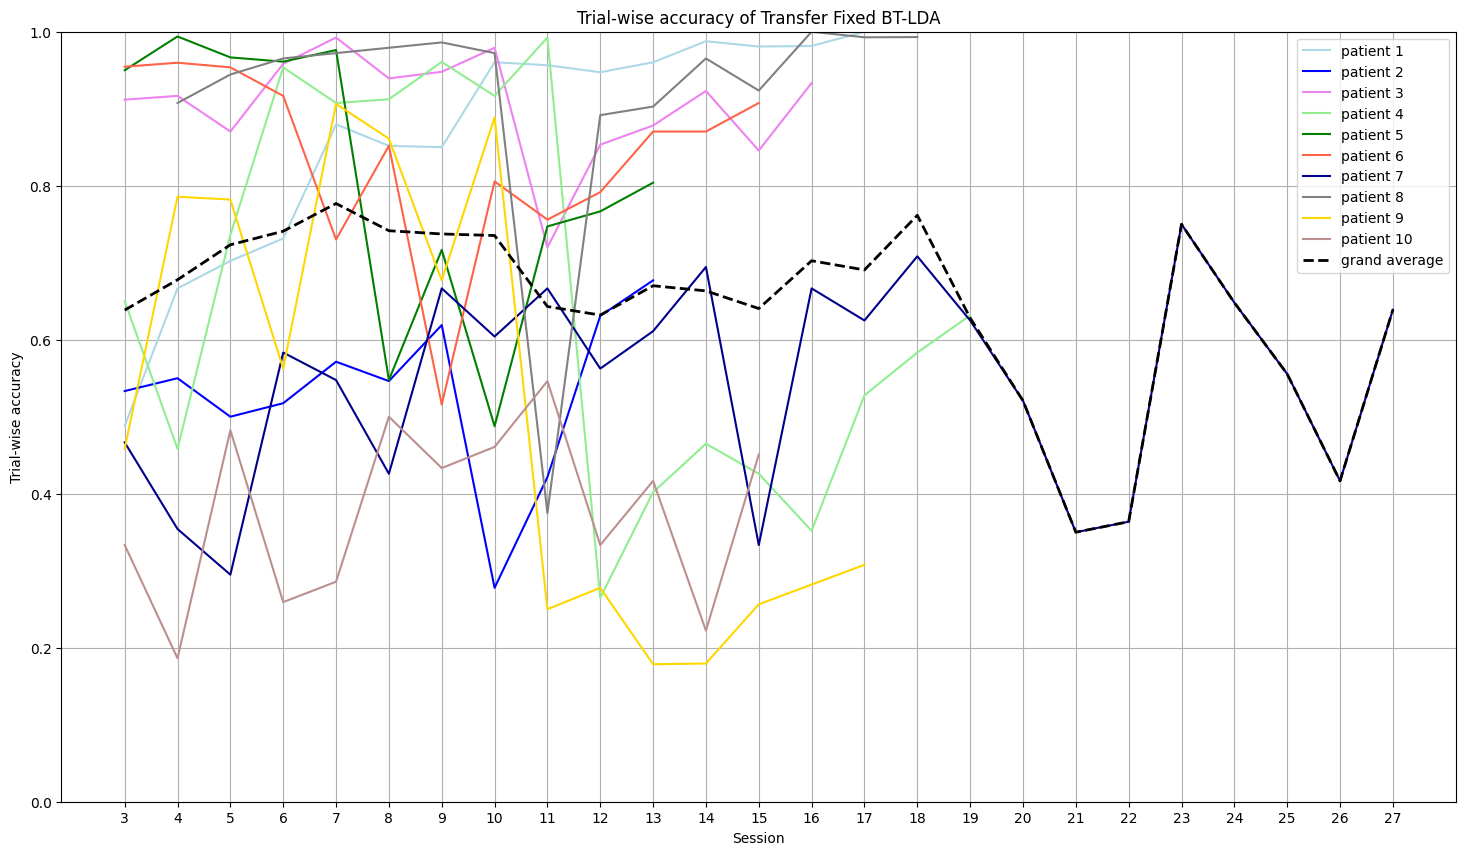

In [8]:
tws_avg = grand_average(tws_scores)
plot_all_patients(tws_scores,tws_avg,"Trial-wise accuracy of Transfer Fixed BT-LDA", ylabel="Trial-wise accuracy", ylim=(0,1))

## window

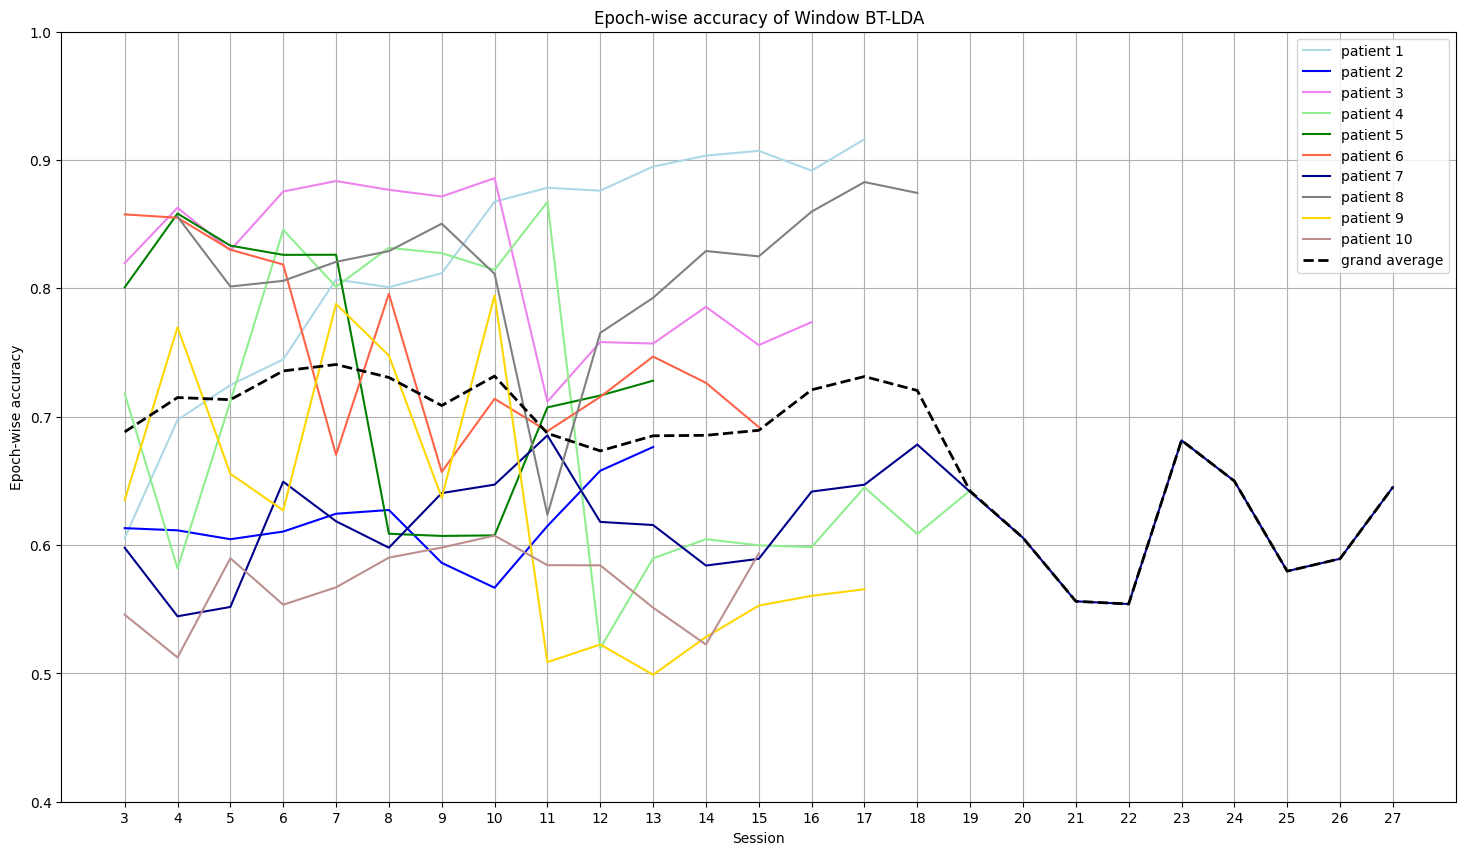

In [8]:
pickle_name = "window_v1"
strategy = "window_v1"
clf = "btlda"
score = "ews"

ews_all_window = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False)
ews_avg_window = grand_average(ews_all_window) 


plot_all_patients(ews_all_window, grand_avg=ews_avg_window, title="Epoch-wise accuracy of Window BT-LDA", ylabel="Epoch-wise accuracy")

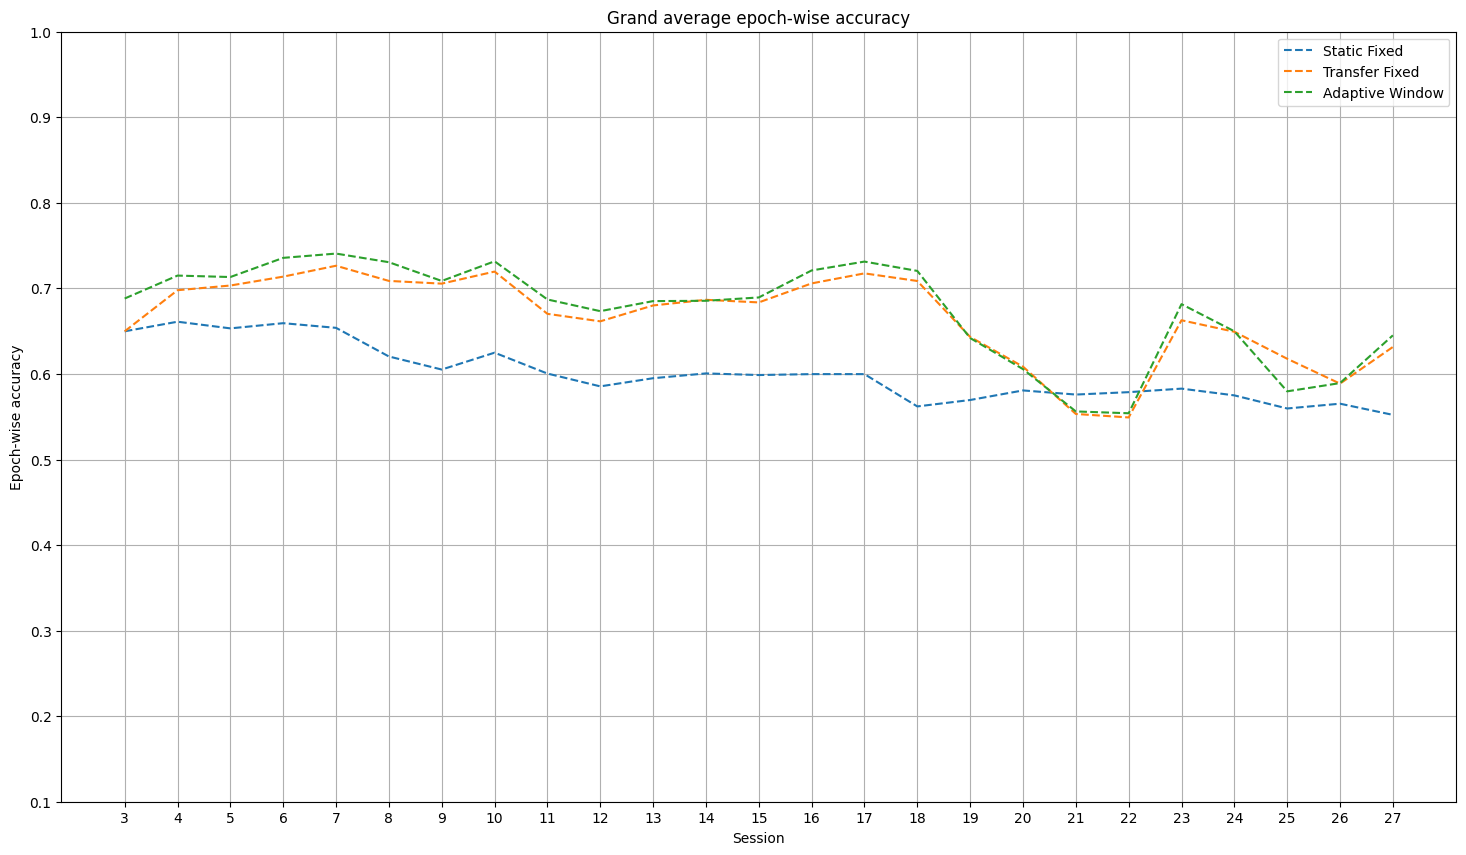

In [9]:
plt.figure(figsize=(18,10))
plt.plot(ews_avg_static, label="Static Fixed", linestyle='dashed')
plt.plot(ews_avg_transfer, label="Transfer Fixed", linestyle='dashed')
plt.plot(ews_avg_window, label="Adaptive Window", linestyle='dashed', color="tab:green")
plt.ylabel("Epoch-wise accuracy")
plt.xlabel('Session')
plt.ylim(0.1,1)
plt.xticks(np.arange(0,25), np.arange(3,28))    
plt.legend()    
plt.title("Grand average epoch-wise accuracy")   
plt.grid() 
plt.show()

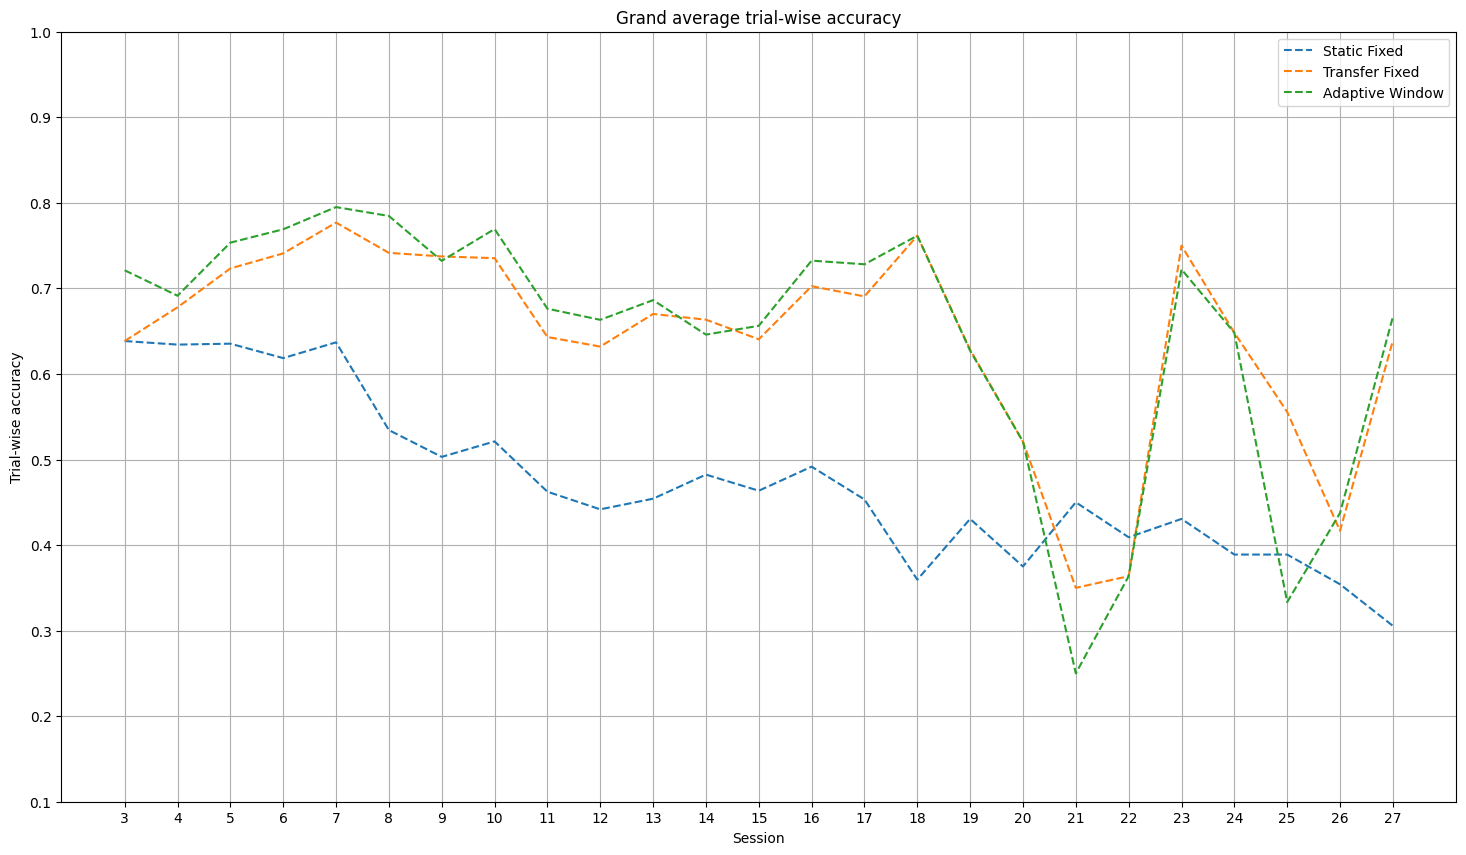

In [13]:
tws_scores_transfer = get_scores_all_patients("performances_v1", strategy="transfer", classifier="btlda", score="tws")
tws_avg_transfer = grand_average(tws_scores_transfer)

tws_scores_static = get_scores_all_patients("performances_static_v1", strategy="static", classifier="btlda", score="tws")
tws_avg_static = grand_average(tws_scores_static)

tws_scores_window = get_scores_all_patients("window_v1", strategy="window_v1", classifier="btlda", score="tws")
tws_avg_window = grand_average(tws_scores_window)

plt.figure(figsize=(18,10))
plt.plot(tws_avg_static, label="Static Fixed", linestyle='dashed')
plt.plot(tws_avg_transfer, label="Transfer Fixed", linestyle='dashed')
plt.plot(tws_avg_window, label="Adaptive Window", linestyle='dashed', color="tab:green")
plt.ylabel("Trial-wise accuracy")
plt.xlabel('Session')
plt.ylim(0.1,1)
plt.xticks(np.arange(0,25), np.arange(3,28))    
plt.legend()    
plt.title("Grand average trial-wise accuracy")   
plt.grid() 
plt.show()